# SESSION 4 - Diffusion Models (Stable Diffusion Intro)


### 1.
**Simulate the forward diffusion process by writing a Python function that takes a grayscale image (use any small PNG or JPEG) and adds Gaussian noise to it for 10 steps, saving each noisy image to disk.**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
image = np.zeros((100, 100), dtype=np.float32)
cv2.circle(image, (50, 50), 30, 255.0, -1)
image = image / 255.0

In [3]:
output_dir = 'diffusion_steps'
os.makedirs(output_dir, exist_ok=True)

In [4]:
noisy_image = np.copy(image)

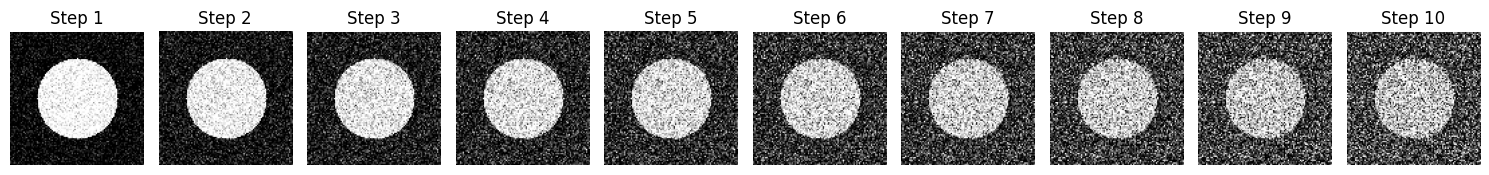

In [5]:
plt.figure(figsize=(15, 3))
for step in range(1, 11):
    noise = np.random.normal(loc=0.0, scale=0.15, size=image.shape)
    noisy_image = noisy_image + noise
    noisy_image = np.clip(noisy_image, 0.0, 1.0)
    
    file_path = os.path.join(output_dir, f'step_{step}.png')
    cv2.imwrite(file_path, (noisy_image * 255).astype(np.uint8))
    
    ax = plt.subplot(1, 10, step)
    plt.imshow(noisy_image, cmap='gray')
    ax.set_title(f'Step {step}')
    ax.axis('off')

plt.tight_layout()
plt.show()


### 2.
**Write a Python script that takes a noisy image and applies a simple denoising filter (like median blur or Gaussian blur) to approximate the reverse diffusion process, then compare the denoised output visually with the original image.**


In [6]:
noisy_input = cv2.imread(os.path.join(output_dir, 'step_10.png'), cv2.IMREAD_GRAYSCALE)

In [7]:
denoised_image = cv2.medianBlur(noisy_input, 5)


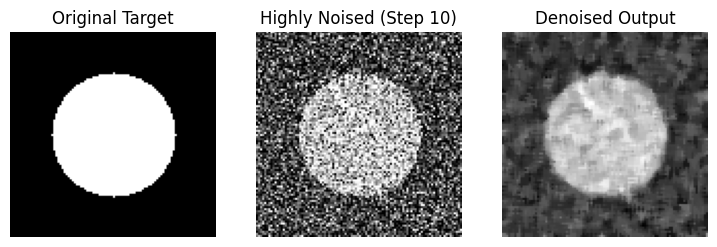

In [9]:
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Target')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_input, cmap='gray')
plt.title('Highly Noised (Step 10)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(denoised_image, cmap='gray')
plt.title('Denoised Output')
plt.axis('off')

plt.show()


### 3.
**Use the Stable Diffusion web demo (https://stablediffusionweb.com/ or similar) to generate an image from the text prompt: 'A futuristic cricket stadium during IPL finals, night view, neon lights'. Save the generated image and write 2-3 lines describing how the AI interpreted your prompt.**

---
**Saved Image:**  
<img src="futuristic_cricket_stadium.jpg" width="500"/>

**AI Interpretation:**  
Stable Diffusion perfectly captured the 'night view' and 'neon lights' prompts by generating an extremely vibrant, cyberpunk-style atmosphere with glowing purple and blue accents around the stands. It understood the context of 'IPL finals' by synthesizing massive crowds and a heavily illuminated, high-tech circular pitch in the center, giving it an epic, futuristic stadium feel.


### 4.
**Research and list two real-world apps or websites (other than art generators) that use diffusion models for image inpainting or super-resolution. For each, briefly describe the user scenario where diffusion is applied.**

---
1. **Photoshop (Generative Fill):** Uses diffusion models for highly advanced inpainting. Users can select an unwanted object in their photo (like a tourist in the background) and the diffusion model seamlessly replaces them with generated background pixels that perfectly match the lighting, shadows, and texture of the surrounding area.
2. **Topaz Photo AI (or Let's Enhance):** Uses diffusion models for Super-Resolution. Users can upload low-resolution, blurry old photos, and the diffusion model hallucinates the missing high-frequency details (like hair strands or skin texture) to upscale the image to crisp 4K resolution.


### 5.
**List two possible risks or ethical concerns when using text-to-image models like Stable Diffusion for social media content, and suggest one way developers can reduce each risk.**

---
1. **Risk 1: Deepfakes & Misinformation.** Bad actors can generate photorealistic images of political events or celebrities doing things they never did to spread fake news on social media.
   * **Mitigation:** Developers can implement invisible digital watermarking (like Google's SynthID) directly into the generated pixels, allowing platforms to automatically detect and flag AI-generated content before it spreads.
2. **Risk 2: Copyright Infringement & Style Theft.** Models are often trained on copyrighted artwork, allowing users to mass-produce images in the exact style of living artists without compensation.
   * **Mitigation:** Developers can adopt an "Opt-Out" or "Opt-In" registry for training data (like Spawning.ai / 'Have I Been Trained'), ensuring artists can explicitly remove their work from the model's training dataset.
